In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import pandas as pd
from scipy.integrate import quad_vec
from scipy.interpolate import interpn
from scipy.special import erf

## Output options

Central switches for saving evaluated temperature data and figures. Everything defaults to off/inline-only so re-running the notebook doesn't write files unless you ask for it.

In [ ]:
import os
import webbrowser
from IPython.display import display


# ---- Data export (temperature field values) ----
# `export_format` applies to every data export below: 'parquet' (default) or 'csv'.
export_format = 'parquet'
save_horizontal_index_data = False       # horizontal plane at the single `index` time step
save_horizontal_animation_data = False   # horizontal plane, all animation frames
save_vertical_index_data = False         # vertical plane at the single `index` time step
save_vertical_animation_data = False     # vertical plane, all animation frames

# ---- Figure export ----
# Static (single time-index) plots -> high-resolution PNG.
# Animations -> a standalone HTML file with the same interactive player shown inline.
save_index_plot_png = False
save_animation_html = False
png_dpi = 300

# ---- 3D (Plotly) plot options ----
# The 3D plots embed their whole animation (all frames) into the notebook's
# cell output when rendered inline, which is what makes the notebook file
# itself balloon in size and get slow to open/scroll -- it's not the FLS
# computation. Turn `render_3d_plots_inline` off to skip that and instead
# always save a standalone HTML file (opened in your browser, optionally
# automatically via `open_3d_plots_in_browser`), which loads plotly.js from
# a CDN instead of embedding it, so the file stays a fraction of the size.
render_3d_plots_inline = True
open_3d_plots_in_browser = False
show_borefield_in_3d = True         # translucent borehole cylinders in the 3D plots
borehole_visual_radius_scale = 10.0  # real borehole radii are tiny vs. the plot extent; exaggerate for visibility (display only, not physical)

export_dir = './visualization_output'
os.makedirs(export_dir, exist_ok=True)


def _export_path(name, extension):
    return os.path.join(export_dir, f'{name}.{extension}')


def _save_dataframe(df, name):
    if export_format == 'parquet':
        path = _export_path(name, 'parquet')
        df.to_parquet(path, index=False)
    elif export_format == 'csv':
        path = _export_path(name, 'csv')
        df.to_csv(path, index=False)
    else:
        raise ValueError(f"export_format must be 'parquet' or 'csv', got {export_format!r}")
    print(f'Saved {path}')


def _save_png(fig, name):
    path = _export_path(name, 'png')
    fig.savefig(path, dpi=png_dpi)
    print(f'Saved {path}')


def _save_animation_html(anim, name):
    path = _export_path(name, 'html')
    with open(path, 'w') as f:
        f.write(anim.to_jshtml())
    print(f'Saved {path}')


def _save_plotly_png(fig, name):
    # Static image export needs the optional `kaleido` package.
    path = _export_path(name, 'png')
    try:
        fig.write_image(path, scale=png_dpi / 96)
    except Exception as exc:
        print(f'Could not save {path} ({exc}). Install the "kaleido" package to enable Plotly PNG export.')
        return
    print(f'Saved {path}')


def _emit_plotly_figure(fig, name):
    """Show/save a Plotly figure per `render_3d_plots_inline` / `save_animation_html`
    / `open_3d_plots_in_browser`. Saved files load plotly.js from a CDN (much
    smaller than embedding it) since they're meant to be opened in a browser
    with internet access."""
    path = _export_path(name, 'html')
    if save_animation_html or not render_3d_plots_inline:
        fig.write_html(path, include_plotlyjs='cdn')
        print(f'Saved {path}')
    if render_3d_plots_inline:
        display(fig)
    elif open_3d_plots_in_browser:
        webbrowser.open('file://' + os.path.abspath(path))
    else:
        print(f'render_3d_plots_inline is False: open {path} in a browser to view it.')


## Import data

### Boreholes

In [3]:
df_boreholes = pd.read_parquet('./export/boreholes.parquet')

In [4]:
zone_ids = sorted(df_boreholes['zone_id'].unique())
grouped_boreholes = df_boreholes.groupby('zone_id', sort=True)

x = [grouped_boreholes.get_group(zone_id)['x_m'].to_numpy() for zone_id in zone_ids]
y = [grouped_boreholes.get_group(zone_id)['y_m'].to_numpy() for zone_id in zone_ids]
H = [grouped_boreholes.get_group(zone_id)['H_m'].to_numpy() for zone_id in zone_ids]
D = [grouped_boreholes.get_group(zone_id)['D_m'].to_numpy() for zone_id in zone_ids]
r_b = [grouped_boreholes.get_group(zone_id)['r_b_m'].to_numpy() for zone_id in zone_ids]

n_zones = len(zone_ids)

Length, buried depth and radius are equal within a zone.

In [5]:
H = np.array([_H[0] for _H in H])
D = np.array([_D[0] for _D in D])
r_b = np.array([_r_b[0] for _r_b in r_b])

### Segments

In [6]:
df_segments = pd.read_parquet('./export/borehole_segments.parquet')

In [7]:
segments = df_segments.merge(
    df_boreholes[['borehole_id', 'zone_id']],
    on='borehole_id',
    how='left',
).sort_values(['zone_id', 'borehole_id', 'segment_id'])
grouped_segments = segments.groupby('zone_id', sort=True)

z_start = [
    grouped_segments.get_group(zone_id)['z_start_m'].to_numpy().reshape(len(x[index]), -1)
    for index, zone_id in enumerate(zone_ids)
]
z_end = [
    grouped_segments.get_group(zone_id)['z_end_m'].to_numpy().reshape(len(x[index]), -1)
    for index, zone_id in enumerate(zone_ids)
]

Borehole discretization is the same for all boreholes within a zone.

In [8]:
D_segments = [_z_start[0] for _z_start in z_start]
H_segments = [_z_end[0] - _z_start[0] for (_z_end, _z_start) in zip(z_end, z_start)]

### Ground properties

In [9]:
df_ground = pd.read_parquet('./export/ground_properties.parquet')

In [10]:
k_s = df_ground['k_soil_W_mK'].to_numpy().item()
alpha_s = k_s / (df_ground['rho_soil_kg_m3'].to_numpy() * df_ground['c_soil_J_kgK'].to_numpy()).item()
T_g = df_ground['T_undisturbed_K'].to_numpy().item()
T_g_gradient = df_ground['gradient_K_m'].to_numpy().item()
z_start_gradient = df_ground['z_start_gradient'].to_numpy().item()
def undisturbed_ground_temperature(z):
    return T_g + T_g_gradient * np.maximum(z - z_start_gradient, 0.)

### Segment heat rates

In [11]:
df_heat = pd.read_parquet('./export/segment_heat_rates.parquet')

In [12]:
time = np.sort(df_heat['time_end_s'].unique())
segment_ids = np.sort(df_heat['segment_id'].unique())

q_by_zone_segment = (
    df_heat.groupby(['time_end_s', 'zone_id', 'segment_id'])['q_segment_W_avg']
    .mean()
    .reindex(
        pd.MultiIndex.from_product(
            [time, zone_ids, segment_ids],
            names=['time_end_s', 'zone_id', 'segment_id'],
        )
    )
)
q_segments = q_by_zone_segment.to_numpy().reshape(
    len(time), len(zone_ids), len(segment_ids)
)

## Visualize borefield

### Top view

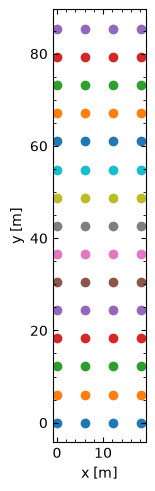

In [13]:
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_aspect('equal', adjustable='box')
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
for i, (_x, _y) in enumerate(zip(x, y)):
        ax.scatter(_x, _y, label=f'Zone {zone_ids[i]}')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

### Side view

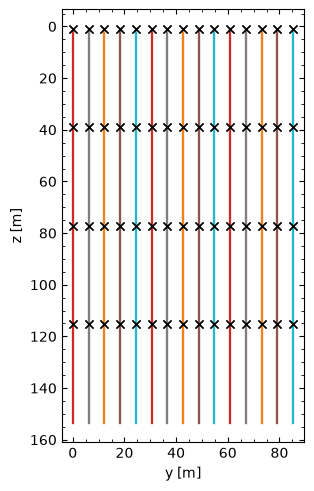

In [14]:
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel('y [m]')
ax.set_ylabel('z [m]')
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
for i, (_y, _D, _H, _D_segments) in enumerate(zip(y, D, H, D_segments)):
        _y_coords = np.tile(_y, (2, 1))
        _z_coords = np.array([_D, _D + _H])
        ax.plot(_y_coords, _z_coords, label=f'Zone {zone_ids[i]}')
        ax.plot(_y_coords.T, _D_segments, 'kx')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

## Evaluation of the temperature field on a horizontal layer

### Parameters

Note: evaluating a vertical plane is slower than a horizontal layer (roughly 20 min vs 5 min on the original author's machine), because depth coordinates are not clustered/reduced for the thermal response factor evaluation, only horizontal radial distances are (see `_cluster_distances` below). A vertical cut is added further down, after the horizontal example.

In [15]:
x_min = df_boreholes['x_m'].min() - 15.0
x_max = df_boreholes['x_m'].max() + 15.0
y_min = df_boreholes['y_m'].min() - 15.0
y_max = df_boreholes['y_m'].max() + 15.0

num_x = 71
num_y = 181
x_T, y_T = np.meshgrid(
    np.linspace(x_min, x_max, num_x),
    np.linspace(y_min, y_max, num_y),
)
z_T = D[0] + H[0] / 2

p_T = np.stack([x_T, y_T, z_T * np.ones_like(x_T)], axis=-1).reshape(-1, 3)

In [16]:
T_g_T = undisturbed_ground_temperature(z_T)

### Finite line source solution

In [17]:
def _cluster_distances(r, relative_tolerance):
    """Return representative distances and their group labels."""
    r = np.asarray(r, dtype=float)
    order = np.argsort(r)
    sorted_r = r[order]
    labels = np.empty(len(r), dtype=int)
    representatives = []

    for sorted_index, distance in enumerate(sorted_r):
        if not representatives or distance > representatives[-1] * (1.0 + relative_tolerance):
            representatives.append(distance)
        labels[order[sorted_index]] = len(representatives) - 1

    return np.asarray(representatives), labels


def zoned_finite_line_source_to_points_reduced_vector(
        p_points, t, alpha, p_boreholes, H, D, r_b,
        relative_tolerance=1e-2, adiabatic_surface=False):
    """Integrate a reduced distance vector and expand it to all points."""
    p_points = np.asarray(p_points, dtype=float)
    p_boreholes = np.asarray(p_boreholes, dtype=float)
    t = np.atleast_1d(np.asarray(t, dtype=float))
    H = np.atleast_1d(np.asarray(H, dtype=float))
    D = np.atleast_1d(np.asarray(D, dtype=float))
    if relative_tolerance < 0:
        raise ValueError('relative_tolerance must be non-negative')

    distances = np.maximum(
        np.hypot(
            p_points[:, None, 0] - p_boreholes[None, :, 0],
            p_points[:, None, 1] - p_boreholes[None, :, 1],
        ),
        r_b,
    )

    reduced_distances = []
    reduced_depths = []
    point_weights = np.zeros((len(p_points), 0))
    for depth in np.unique(p_points[:, 2]):
        point_indices = np.flatnonzero(p_points[:, 2] == depth)
        representatives, labels = _cluster_distances(
            distances[point_indices].ravel(), relative_tolerance
        )
        weights = np.zeros((len(point_indices), len(representatives)))
        np.add.at(weights, (np.repeat(np.arange(len(point_indices)), distances.shape[1]), labels), 1.0)
        point_weights = np.pad(
            point_weights,
            ((0, 0), (0, len(representatives))),
        )
        point_weights[point_indices, -len(representatives):] = weights
        reduced_distances.extend(representatives)
        reduced_depths.extend([depth] * len(representatives))

    reduced_distances = np.asarray(reduced_distances)
    reduced_depths = np.asarray(reduced_depths)
    reduced_count = len(reduced_distances)

    def _integrand(s):
        decay = np.exp(-(reduced_distances * s) ** 2) / s
        real = erf((D[None, :] + H[None, :] - reduced_depths[:, None]) * s)
        real -= erf((D[None, :] - reduced_depths[:, None]) * s)
        mirror = erf((D[None, :] + H[None, :] + reduced_depths[:, None]) * s)
        mirror -= erf((D[None, :] + reduced_depths[:, None]) * s)
        surface_term = real + mirror if adiabatic_surface else real - mirror
        return (0.5 * decay[:, None] * surface_term).reshape(reduced_count * len(H))

    lower_limits = 1.0 / np.sqrt(4.0 * alpha * t)
    h_reduced = np.stack(
        [quad_vec(_integrand, lower_limit, np.inf)[0] for lower_limit in lower_limits],
        axis=0,
    ).reshape(len(t), reduced_count, len(H))
    return np.einsum('pg,tgs->tps', point_weights, h_reduced)

In [18]:
time_reduced = []
_t = 0.
_dt = time[0]
_level = 0
_cells_per_level = 6
_cells_in_level = 0
while _t < time[-1]:
    _t += _dt
    time_reduced.append(_t)
    _cells_in_level += 1
    if _cells_in_level >= _cells_per_level:
        _level += 1
        _cells_per_level *= 2
        _cells_in_level = 0
        _dt *= 2
time_reduced = np.array(time_reduced)

In [ ]:
relative_tolerance = 1e-2
h_zoned_reduced_vector = [
    zoned_finite_line_source_to_points_reduced_vector(
        p_T,
        time_reduced,
        alpha_s,
        np.stack([_x, _y], axis=-1),
        _H_segments,
        _D_segments,
        _r_b,
        relative_tolerance=relative_tolerance,
    )
    for _x, _y, _H_segments, _D_segments, _r_b in zip(
        x, y, H_segments, D_segments, r_b
    )
]

In [ ]:
h_zoned = [interpn((time_reduced,), _h_zoned, time, method='linear') for _h_zoned in h_zoned_reduced_vector]

In [ ]:
kappa_zoned = [
    np.diff(_h, axis=0, prepend=np.zeros((1, _h.shape[1], _h.shape[2]))) / (2 * np.pi * k_s * _H_segments)
    for _h, _H_segments in zip(h_zoned, H_segments)
]

### Temperature field at prescribed time index

In [ ]:
# time step to visualize: end of the simulation
index = len(time) - 1

In [ ]:
# superpose each zone's segment step-responses up to `index` (see Temperature_visualization.md, section 2)
T = np.ravel(T_g_T)
for _kappa_zoned, _q_segments in zip(kappa_zoned, q_segments.swapaxes(0, 1)):
    T = T + np.einsum('tps,ts->p', _kappa_zoned[:index+1], _q_segments[index::-1])

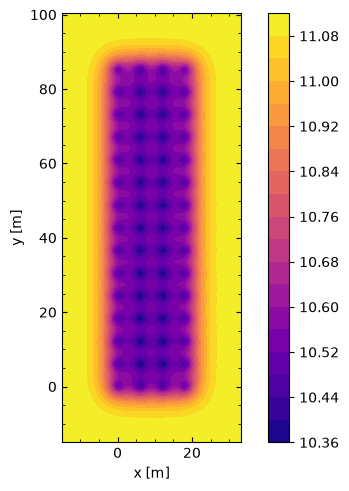

In [ ]:
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_aspect('equal', adjustable='box')
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
ax.contourf(x_T, y_T, T.reshape(x_T.shape) - 273.15, levels=20, cmap='plasma')
cb = fig.colorbar(ax.collections[0], ax=ax)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
if save_index_plot_png:
    _save_png(fig, 'horizontal_plane_index')
if save_horizontal_index_data:
    df_T_horizontal_index = pd.DataFrame({
        'x_m': x_T.ravel(),
        'y_m': y_T.ravel(),
        'z_m': np.full(x_T.size, z_T),
        'T_K': T,
        'T_C': T - 273.15,
    })
    _save_dataframe(df_T_horizontal_index, 'horizontal_plane_index')


### Animation over time

Same horizontal slice as above, played back as an animation. At most
`max_frames` time steps, evenly spaced, are evaluated. This keeps both the
computation and the resulting file size manageable for much longer
simulations too. The color scale is fixed to the min/max over the whole
simulation so colors stay comparable from frame to frame.

In [ ]:
# cap the number of animated frames: with long simulations (e.g. years of data)
# evaluating every time step would be both slow (cost grows with time index) and
# produce an unplayably large animation, so pick at most `max_frames` steps, evenly
# spaced in time
max_frames = 150
frame_indices = np.unique(np.linspace(0, len(time) - 1, min(len(time), max_frames)).round().astype(int))
frame_times = time[frame_indices]

# same superposition as above (see cell computing `T`), repeated for every selected time index
T_all = np.empty((len(frame_indices), x_T.size))
T_g_flat = np.ravel(T_g_T)
for frame, i in enumerate(frame_indices):
    T_i = T_g_flat.copy()
    for _kappa_zoned, _q_segments in zip(kappa_zoned, q_segments.swapaxes(0, 1)):
        T_i = T_i + np.einsum('tps,ts->p', _kappa_zoned[:i+1], _q_segments[i::-1])
    T_all[frame] = T_i

T_all_C = T_all.reshape(len(frame_indices), *x_T.shape) - 273.15

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

vmin, vmax = T_all_C.min(), T_all_C.max()

# smaller figure/dpi than the static plot above: the animation embeds one PNG per
# frame in the notebook output, so this keeps the saved file size reasonable
fig, ax = plt.subplots(figsize=(4.5, 5.5), dpi=80, constrained_layout=True)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_aspect('equal', adjustable='box')
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
mesh = ax.pcolormesh(x_T, y_T, T_all_C[0], shading='gouraud', cmap='plasma', vmin=vmin, vmax=vmax)
cb = fig.colorbar(mesh, ax=ax)
cb.set_label('Ground temperature [°C]')
title = ax.set_title(f't = {frame_times[0] / 86400:.0f} d')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

def _update(frame):
    mesh.set_array(T_all_C[frame].ravel())
    title.set_text(f't = {frame_times[frame] / 86400:.0f} d')
    return mesh, title

anim = FuncAnimation(fig, _update, frames=len(frame_indices), interval=200)
plt.close(fig)  # prevent a duplicate static figure from being displayed below
if save_animation_html:
    _save_animation_html(anim, 'horizontal_plane_animation')
if save_horizontal_animation_data:
    df_T_horizontal_animation = pd.DataFrame({
        'frame': np.repeat(np.arange(len(frame_indices)), x_T.size),
        'time_s': np.repeat(frame_times, x_T.size),
        'x_m': np.tile(x_T.ravel(), len(frame_indices)),
        'y_m': np.tile(y_T.ravel(), len(frame_indices)),
        'z_m': np.tile(np.full(x_T.size, z_T), len(frame_indices)),
        'T_C': T_all_C.reshape(len(frame_indices), -1).ravel(),
    })
    _save_dataframe(df_T_horizontal_animation, 'horizontal_plane_animation')

HTML(anim.to_jshtml())

## Evaluation of the temperature field on a vertical plane

A y-z cut at fixed `x`, through the middle of the borefield.

In [ ]:
# mid-x of the borefield, derived from the actual borehole coordinates
x_mid = 0.5 * (df_boreholes['x_m'].min() + df_boreholes['x_m'].max())

y_min_v = df_boreholes['y_m'].min() - 15.0
y_max_v = df_boreholes['y_m'].max() + 15.0
z_min_v = 0.0
z_max_v = D[0] + H[0] + 15.0

num_y_v = 181
num_z_v = 15  # kept coarse: see the note above on why vertical evaluation is slow
y_Tv, z_Tv = np.meshgrid(
    np.linspace(y_min_v, y_max_v, num_y_v),
    np.linspace(z_min_v, z_max_v, num_z_v),
)

p_Tv = np.stack([x_mid * np.ones_like(y_Tv), y_Tv, z_Tv], axis=-1).reshape(-1, 3)
T_g_Tv = undisturbed_ground_temperature(z_Tv)

In [ ]:
# reuses zoned_finite_line_source_to_points_reduced_vector, time_reduced and
# relative_tolerance from the horizontal section above; this is the slow cell
# (a few minutes) discussed in the note above
h_zoned_reduced_vector_v = [
    zoned_finite_line_source_to_points_reduced_vector(
        p_Tv,
        time_reduced,
        alpha_s,
        np.stack([_x, _y], axis=-1),
        _H_segments,
        _D_segments,
        _r_b,
        relative_tolerance=relative_tolerance,
    )
    for _x, _y, _H_segments, _D_segments, _r_b in zip(
        x, y, H_segments, D_segments, r_b
    )
]

In [ ]:
h_zoned_v = [interpn((time_reduced,), _h, time, method='linear') for _h in h_zoned_reduced_vector_v]
kappa_zoned_v = [
    np.diff(_h, axis=0, prepend=np.zeros((1, _h.shape[1], _h.shape[2]))) / (2 * np.pi * k_s * _H_segments)
    for _h, _H_segments in zip(h_zoned_v, H_segments)
]

In [ ]:
# same time index and superposition as the horizontal plot above
T_v = np.ravel(T_g_Tv)
for _kappa_zoned, _q_segments in zip(kappa_zoned_v, q_segments.swapaxes(0, 1)):
    T_v = T_v + np.einsum('tps,ts->p', _kappa_zoned[:index+1], _q_segments[index::-1])

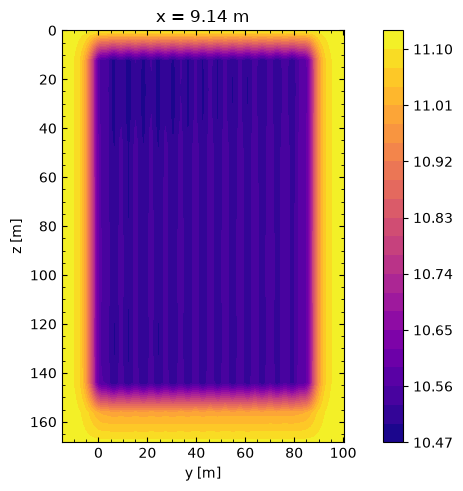

In [ ]:
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel('y [m]')
ax.set_ylabel('z [m]')
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
ax.contourf(y_Tv, z_Tv, T_v.reshape(y_Tv.shape) - 273.15, levels=20, cmap='plasma')
cb = fig.colorbar(ax.collections[0], ax=ax)
ax.set_title(f'x = {x_mid:.2f} m')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
if save_index_plot_png:
    _save_png(fig, 'vertical_plane_index')
if save_vertical_index_data:
    df_T_vertical_index = pd.DataFrame({
        'x_m': np.full(y_Tv.size, x_mid),
        'y_m': y_Tv.ravel(),
        'z_m': z_Tv.ravel(),
        'T_K': T_v,
        'T_C': T_v - 273.15,
    })
    _save_dataframe(df_T_vertical_index, 'vertical_plane_index')


### Animation over time

In [ ]:
# same superposition as above, repeated for every selected time index (see the
# horizontal animation cell for why `frame_indices` is reused here)
T_all_v = np.empty((len(frame_indices), y_Tv.size))
T_g_Tv_flat = np.ravel(T_g_Tv)
for frame, i in enumerate(frame_indices):
    T_i = T_g_Tv_flat.copy()
    for _kappa_zoned, _q_segments in zip(kappa_zoned_v, q_segments.swapaxes(0, 1)):
        T_i = T_i + np.einsum('tps,ts->p', _kappa_zoned[:i+1], _q_segments[i::-1])
    T_all_v[frame] = T_i

T_all_v_C = T_all_v.reshape(len(frame_indices), *y_Tv.shape) - 273.15

In [ ]:
vmin_v, vmax_v = T_all_v_C.min(), T_all_v_C.max()

fig, ax = plt.subplots(figsize=(4.5, 5.5), dpi=80, constrained_layout=True)
ax.set_xlabel('y [m]')
ax.set_ylabel('z [m]')
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
mesh_v = ax.pcolormesh(y_Tv, z_Tv, T_all_v_C[0], shading='gouraud', cmap='plasma', vmin=vmin_v, vmax=vmax_v)
cb = fig.colorbar(mesh_v, ax=ax)
cb.set_label('Ground temperature [°C]')
title_v = ax.set_title(f'x = {x_mid:.2f} m, t = {frame_times[0] / 86400:.0f} d')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

def _update_v(frame):
    mesh_v.set_array(T_all_v_C[frame].ravel())
    title_v.set_text(f'x = {x_mid:.2f} m, t = {frame_times[frame] / 86400:.0f} d')
    return mesh_v, title_v

anim_v = FuncAnimation(fig, _update_v, frames=len(frame_indices), interval=200)
plt.close(fig)  # prevent a duplicate static figure from being displayed below
if save_animation_html:
    _save_animation_html(anim_v, 'vertical_plane_animation')
if save_vertical_animation_data:
    df_T_vertical_animation = pd.DataFrame({
        'frame': np.repeat(np.arange(len(frame_indices)), y_Tv.size),
        'time_s': np.repeat(frame_times, y_Tv.size),
        'x_m': np.tile(np.full(y_Tv.size, x_mid), len(frame_indices)),
        'y_m': np.tile(y_Tv.ravel(), len(frame_indices)),
        'z_m': np.tile(z_Tv.ravel(), len(frame_indices)),
        'T_C': T_all_v_C.reshape(len(frame_indices), -1).ravel(),
    })
    _save_dataframe(df_T_vertical_animation, 'vertical_plane_animation')

HTML(anim_v.to_jshtml())

### Borefield geometry (for 3D plots)

Light, translucent cylinders, one per borehole, used as visual context in the 3D plots below: they show where the horizontal/vertical planes cut through the borefield without hiding the temperature data.

In [ ]:
def borefield_mesh3d_trace(x, y, D, H, r_b, radius_scale=None, n_theta=12, color='dimgray', opacity=0.35):
    """A single merged Mesh3d trace with one (open, unshaded-cap) cylinder per
    borehole (`x`, `y`: lists of per-zone borehole coordinate arrays; `D`,
    `H`, `r_b`: per-zone scalars, as produced above for `x`, `y`, `D`, `H`,
    `r_b`). Merging every borehole into one trace (instead of one trace per
    borehole) keeps this fast and light even for large borefields, and the
    `radius_scale` exaggerates the (otherwise near-invisible) real borehole
    radius for visibility -- it's a display setting, not physical.
    """
    if radius_scale is None:
        radius_scale = borehole_visual_radius_scale
    theta = np.linspace(0, 2 * np.pi, n_theta, endpoint=False)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    idx = np.arange(n_theta)
    idx_next = (idx + 1) % n_theta

    vx, vy, vz, fi, fj, fk = [], [], [], [], [], []
    offset = 0
    for zone_x, zone_y, zone_D, zone_H, zone_r_b in zip(x, y, D, H, r_b):
        radius = zone_r_b * radius_scale
        for bh_x, bh_y in zip(zone_x, zone_y):
            vx.append(bh_x + radius * cos_t); vy.append(bh_y + radius * sin_t); vz.append(np.full(n_theta, zone_D))
            vx.append(bh_x + radius * cos_t); vy.append(bh_y + radius * sin_t); vz.append(np.full(n_theta, zone_D + zone_H))
            i1, i2 = offset + idx, offset + idx_next
            i3, i4 = offset + n_theta + idx, offset + n_theta + idx_next
            fi.append(i1); fj.append(i2); fk.append(i3)
            fi.append(i2); fj.append(i4); fk.append(i3)
            offset += 2 * n_theta

    return go.Mesh3d(
        x=np.concatenate(vx), y=np.concatenate(vy), z=np.concatenate(vz),
        i=np.concatenate(fi), j=np.concatenate(fj), k=np.concatenate(fk),
        color=color, opacity=opacity, flatshading=True, hoverinfo='skip', name='boreholes',
    )


### 3D, rotatable version

Same data (`T_all_v_C`) as the animation above, shown as a surface floating
in a 3D `x, y, z` box using [Plotly](https://plotly.com/python/) instead of
matplotlib: drag to rotate/zoom, and use the play button or slider to step
through time. This needs the `plotly` package (not one of the notebook's
existing dependencies). 

In [ ]:
import plotly.graph_objects as go

X_v = x_mid * np.ones_like(y_Tv)

# only `surfacecolor` changes between frames: x/y/z stay fixed, so they're
# omitted from each frame to avoid re-sending the same grid ~150 times
base_surface = go.Surface(
    x=X_v, y=y_Tv, z=z_Tv, surfacecolor=T_all_v_C[0],
    cmin=vmin_v, cmax=vmax_v, colorscale='Plasma',
    colorbar=dict(title='Ground<br>temperature [°C]'),
)
frames_3d = [
    go.Frame(data=[go.Surface(surfacecolor=T_all_v_C[frame])], name=str(frame))
    for frame in range(len(frame_indices))
]

vert_3d_data = [base_surface]
if show_borefield_in_3d:
    vert_3d_data = vert_3d_data + [borefield_mesh3d_trace(x, y, D, H, r_b)]

fig_3d = go.Figure(
    data=vert_3d_data,
    frames=frames_3d,
    layout=go.Layout(
        scene=dict(
            xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='z [m]',
            zaxis=dict(autorange='reversed'),  # depth increases downward
            # 'data' aspect mode degenerates here since x doesn't vary (it's a
            # single plane) — set the box proportions by hand instead, with
            # y:z matching their actual extent ratio and a thin x so the
            # plane doesn't get squashed into a tiny corner of the figure
            aspectmode='manual',
            aspectratio=dict(x=0.3, y=1, z=(z_max_v - z_min_v) / (y_max_v - y_min_v)),
        ),
        title=f'Vertical plane at x = {x_mid:.2f} m',
        width=850,
        height=950,
        margin=dict(l=0, r=0, t=60, b=0),
        updatemenus=[dict(type='buttons', buttons=[
            dict(label='Play', method='animate',
                 args=[None, {'frame': {'duration': 200, 'redraw': True}, 'fromcurrent': True}]),
            dict(label='Pause', method='animate',
                 args=[[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]),
        ])],
        sliders=[dict(steps=[
            dict(method='animate', args=[[str(frame)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}}],
                 label=f'{frame_times[frame] / 86400:.0f} d')
            for frame in range(len(frame_indices))
        ])],
    ),
)
_emit_plotly_figure(fig_3d, 'vertical_plane_3d')

## Combined 3D view: horizontal + vertical planes together

Same frames (`frame_indices` / `frame_times`) and data (`T_all_C`, `T_all_v_C`) as the two animations above, just drawn in one 3D scene instead of two separate 2D ones. No new temperature evaluation is needed here.

In [ ]:
X_v = x_mid * np.ones_like(y_Tv)

horizontal_surface = go.Surface(
    x=x_T, y=y_T, z=z_T * np.ones_like(x_T), surfacecolor=T_all_C[0],
    cmin=min(vmin, vmin_v), cmax=max(vmax, vmax_v), colorscale='Plasma',
    colorbar=dict(title='Ground<br>temperature [°C]'),
    name='horizontal plane',
)
vertical_surface = go.Surface(
    x=X_v, y=y_Tv, z=z_Tv, surfacecolor=T_all_v_C[0],
    cmin=min(vmin, vmin_v), cmax=max(vmax, vmax_v), colorscale='Plasma',
    showscale=False,
    name='vertical plane',
)

combined_data = [horizontal_surface, vertical_surface]
if show_borefield_in_3d:
    combined_data = combined_data + [borefield_mesh3d_trace(x, y, D, H, r_b)]

combined_frames = [
    go.Frame(
        data=[
            go.Surface(surfacecolor=T_all_C[frame]),
            go.Surface(surfacecolor=T_all_v_C[frame]),
        ],
        traces=[0, 1],
        name=str(frame),
    )
    for frame in range(len(frame_indices))
]

fig_3d_combined = go.Figure(
    data=combined_data,
    frames=combined_frames,
    layout=go.Layout(
        scene=dict(
            xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='z [m]',
            zaxis=dict(autorange='reversed'),
            aspectmode='data',
        ),
        title='Horizontal plane (fixed z) and vertical plane (fixed x)',
        width=900,
        height=950,
        margin=dict(l=0, r=0, t=60, b=0),
        updatemenus=[dict(type='buttons', buttons=[
            dict(label='Play', method='animate',
                 args=[None, {'frame': {'duration': 200, 'redraw': True}, 'fromcurrent': True}]),
            dict(label='Pause', method='animate',
                 args=[[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]),
        ])],
        sliders=[dict(steps=[
            dict(method='animate', args=[[str(frame)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}}],
                 label=f'{frame_times[frame] / 86400:.0f} d')
            for frame in range(len(frame_indices))
        ])],
    ),
)

if save_index_plot_png:
    _save_plotly_png(fig_3d_combined, 'combined_3d_planes_index')

_emit_plotly_figure(fig_3d_combined, 'combined_3d_planes_animation')
